# 0. Data Layers Overview

Этот notebook показывает, как работать с текущими слоями данных в проекте.

Что именно мы хотим увидеть:
- что такое **raw layer** и какие таблицы в нём уже доступны;
- что даёт **canonical layer** поверх сырых таблиц;
- какие **derived panels** уже реально строятся поверх этих слоёв;
- какие простые sanity-check графики и статистики подтверждают, что данные выглядят осмысленно.

Основная идея архитектуры здесь такая:
1. `raw` хранит source-of-truth таблицы почти без research-интерпретации;
2. `canonical` добавляет стабильные, удобные для downstream-слоёв поля;
3. `derived representations` строят task-ready панели вроде `terminal`, `repricing` и `shock_table`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import tempfile

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'research_notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from polymarket_research import PolymarketDataset
from polymarket_research.data import PolymarketDatasetBuilder
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates
from polymarket_research.utils import setup_root

REPO_ROOT = setup_root(REPO_ROOT)
RAW_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts'
USE_PARQUET_CACHE = (RAW_CACHE_DIR / 'markets.parquet').exists() and (RAW_CACHE_DIR / 'probabilities.parquet').exists()

DOMAINS = ('politics', 'geopolitics', 'technology', 'finance_economy')
PLOT_STYLE = 'seaborn-v0_8-whitegrid'

plt.style.use(PLOT_STYLE)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)


## Небольшие helper-функции

Эти функции не меняют данные, а только помогают делать одни и те же summaries и графики аккуратнее.

Идейно важны две вещи:
- все агрегаты должны быть прозрачными и легко читаемыми;
- для daily active market count лучше использовать `created_at` и `end_date`, а не пытаться каждый раз пересканировать весь probability panel.


In [2]:
def format_large_number(value: float | int | None) -> str:
    """Format large numbers into compact human-readable strings."""
    if value is None or pd.isna(value):
        return 'NA'
    value = float(value)
    if abs(value) >= 1_000_000_000:
        return f'{value / 1_000_000_000:.2f}B'
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:.2f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:.1f}K'
    return f'{value:.2f}'


def build_active_markets_daily(markets_df: pd.DataFrame, *, by_domain: bool = False) -> pd.DataFrame:
    """Build daily active-market counts from created/end timestamps."""
    work = markets_df[['market_id', 'primary_domain', 'created_at', 'end_date']].dropna(subset=['created_at', 'end_date']).copy()
    work['start_day'] = work['created_at'].dt.floor('D')
    work['end_plus_one'] = work['end_date'].dt.floor('D') + pd.Timedelta(days=1)

    if by_domain:
        starts = work.groupby(['start_day', 'primary_domain']).size().rename('delta').reset_index()
        starts['delta'] = 1
        ends = work.groupby(['end_plus_one', 'primary_domain']).size().rename('delta').reset_index()
        ends['delta'] = -1
        ends = ends.rename(columns={'end_plus_one': 'start_day'})
        deltas = pd.concat([starts, ends], ignore_index=True)

        calendar = pd.date_range(work['start_day'].min(), work['end_plus_one'].max() - pd.Timedelta(days=1), freq='D', tz='UTC')
        domains = sorted(work['primary_domain'].dropna().unique())
        idx = pd.MultiIndex.from_product([calendar, domains], names=['day', 'primary_domain'])
        daily = (
            deltas.groupby(['start_day', 'primary_domain'])['delta'].sum()
            .rename_axis(index=['day', 'primary_domain'])
            .reindex(idx, fill_value=0)
            .reset_index()
        )
        daily['active_markets'] = daily.groupby('primary_domain')['delta'].cumsum()
        return daily.drop(columns='delta')

    starts = work.groupby('start_day').size().rename('delta').reset_index()
    starts['delta'] = starts['delta'].astype(int)
    ends = work.groupby('end_plus_one').size().rename('delta').reset_index()
    ends['delta'] = -ends['delta'].astype(int)
    ends = ends.rename(columns={'end_plus_one': 'start_day'})
    deltas = pd.concat([starts, ends], ignore_index=True)

    calendar = pd.date_range(work['start_day'].min(), work['end_plus_one'].max() - pd.Timedelta(days=1), freq='D', tz='UTC')
    daily = pd.DataFrame({'day': calendar})
    delta_by_day = deltas.groupby('start_day')['delta'].sum().rename_axis('day').reset_index()
    daily = daily.merge(delta_by_day, on='day', how='left').fillna({'delta': 0})
    daily['active_markets'] = daily['delta'].cumsum().astype(int)
    return daily.drop(columns='delta')


def top_market_table(markets_df: pd.DataFrame, *, n: int = 10) -> pd.DataFrame:
    """Return the highest-volume markets with a compact set of readable columns."""
    cols = ['market_id', 'primary_domain', 'question', 'volume_num', 'trade_rows', 'probability_rows', 'created_at', 'end_date']
    available = [col for col in cols if col in markets_df.columns]
    return markets_df[available].sort_values('volume_num', ascending=False, kind='stable').head(n).reset_index(drop=True)


## Raw layer: загрузка базовых таблиц

Здесь мы загружаем основной `PolymarketDataset` и отдельно внешний raw layer.

Смысл raw layer:
- ничего не вычислять сверх необходимого;
- сохранить таблицы в максимально исходном виде;
- использовать их как source of truth для всех следующих слоёв.


In [3]:
raw_dataset = PolymarketDataset(
    domains=DOMAINS,
    max_markets_per_domain=500,
    min_probability_rows=288,
)
raw_dataset.load()
raw_dataset.save(RAW_CACHE_DIR)

,file,rows,cols
0,markets.parquet,2000,21
1,probabilities.parquet,39177164,7


In [4]:
if USE_PARQUET_CACHE:
    print('Loading from parquet cache')
    raw_dataset = PolymarketDataset.from_parquet(RAW_CACHE_DIR)
    raw_source_label = f'parquet cache: {RAW_CACHE_DIR}'
else:
    raw_dataset = PolymarketDataset(
        domains=DOMAINS,
        max_markets_per_domain=500,
        min_probability_rows=288,
    )
    raw_dataset.load()
    raw_dataset.save(RAW_CACHE_DIR)
    raw_source_label = f'sqlite: {raw_dataset.db_path}'

raw_external = RawExternalCovariates().load()

print('Raw source:', raw_source_label)
print('External cached path:', raw_external.path)


Loading from parquet cache
Raw source: parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts
External cached path: /Users/sneddy/research/polymarket_research/cached_data/external_covariates


## Raw layer: shapes и базовая инвентаризация

Первая таблица нужна как very fast sanity check: какие raw tables вообще загружены и какого они размера.

Это полезно потому, что дальше все графики и derived panels должны быть соразмерны именно этим базовым объёмам.


In [5]:
raw_summary = raw_dataset.summary().copy()
raw_summary['rows_human'] = raw_summary['rows'].map(format_large_number)
display(raw_summary)

external_summary = pd.DataFrame([
    {
        'name': 'external_covariates',
        'loaded': raw_external.is_loaded,
        'rows': 0 if raw_external.covariates is None else len(raw_external.covariates),
        'cols': 0 if raw_external.covariates is None else raw_external.covariates.shape[1],
        'rows_human': format_large_number(0 if raw_external.covariates is None else len(raw_external.covariates)),
    }
])
display(external_summary)


,name,loaded,rows,cols,rows_human
0,markets,True,3505,16,3.5K
1,probabilities,True,57147087,7,57.15M


,name,loaded,rows,cols,rows_human
0,external_covariates,True,263808,19,263.8K


## Raw layer: какие колонки у нас есть

Перед тем как что-то агрегировать, полезно увидеть минимальный schema inventory.

Особенно важны:
- в `markets`: временные поля, домен, outcome и агрегаты по рынку;
- в `probabilities`: timestamp, probability, trade markers и volume-like поля;
- во внешних covariates: `series_id`, `timestamp_utc`, `value` и при наличии OHLCV-поля.


In [6]:
raw_dataset.short_markets

,market_id,question,primary_domain,probability_start_utc,probability_end_utc,final_outcome
0,546814,Will Zelenskyy wear a suit before July?,politics,2025-05-22 22:55:00+00:00,2025-07-09 00:35:00+00:00,No
1,680392,US government shutdown Saturday?,politics,2025-11-13 15:35:00+00:00,2026-02-04 00:40:00+00:00,Yes
2,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,politics,2025-04-22 18:30:00+00:00,2025-11-05 05:50:00+00:00,Yes
3,529278,Will Frances Fitzgerald win the Irish Presidential Election?,politics,2025-03-21 12:40:00+00:00,2025-10-25 21:20:00+00:00,No
4,519075,Will Hunor Kelemen win the Romanian presidential election?,politics,2025-01-17 23:15:00+00:00,2025-05-16 20:50:00+00:00,No
...,...,...,...,...,...,...
3500,558542,Will Trump agree to a tariff agreement with Japan in July?,finance_economy,2025-07-02 06:40:00+00:00,2025-07-23 05:25:00+00:00,Yes
3501,968503,Will $DJT's market cap be less than 3.5b,finance_economy,2025-12-19 05:15:00+00:00,2025-12-31 23:35:00+00:00,No
3502,551585,Will annual inflation increase by 2.3% in June?,finance_economy,2025-06-11 19:05:00+00:00,2025-07-15 12:40:00+00:00,No
3503,575239,Will monthly inflation increase by 0.1% in August?,finance_economy,2025-08-13 00:55:00+00:00,2025-09-11 12:35:00+00:00,No


In [7]:
raw_dataset.probabilities

,market_id,timestamp_utc,yes_probability,observed_trade,trade_count,total_size,last_trade_price
0,1004795,2025-12-24 14:10:00+00:00,0.680,1,2,5.88235,0.320
1,1004795,2025-12-24 14:15:00+00:00,0.660,1,2,5.88000,0.340
2,1004795,2025-12-24 14:20:00+00:00,0.660,0,0,0.00000,NaN
3,1004795,2025-12-24 14:25:00+00:00,0.660,0,0,0.00000,NaN
4,1004795,2025-12-24 14:30:00+00:00,0.660,0,0,0.00000,NaN
...,...,...,...,...,...,...,...
57147082,999507,2026-01-02 18:25:00+00:00,0.001,0,0,0.00000,NaN
57147083,999507,2026-01-02 18:30:00+00:00,0.001,0,0,0.00000,NaN
57147084,999507,2026-01-02 18:35:00+00:00,0.001,0,0,0.00000,NaN
57147085,999507,2026-01-02 18:40:00+00:00,0.001,1,2,2.06000,0.999


In [8]:
raw_external.short_covariates

,series_id,timestamp_utc,close_timestamp_utc,open,high,low,close,volume,quote_asset_volume,trade_count
0,btc_usd,2025-01-01 00:00:00+00:00,2025-01-01 00:04:59.999000+00:00,93576.00,93702.15,93537.50,93661.20,45.94160,4.301907e+06,7448
1,btc_usd,2025-01-01 00:05:00+00:00,2025-01-01 00:09:59.999000+00:00,93661.20,93678.02,93600.00,93607.10,71.94585,6.736121e+06,4165
2,btc_usd,2025-01-01 00:10:00+00:00,2025-01-01 00:14:59.999000+00:00,93607.10,93656.19,93489.03,93656.18,57.96928,5.423766e+06,8175
3,btc_usd,2025-01-01 00:15:00+00:00,2025-01-01 00:19:59.999000+00:00,93656.19,93840.05,93614.95,93796.35,39.74456,3.727084e+06,8031
4,btc_usd,2025-01-01 00:20:00+00:00,2025-01-01 00:24:59.999000+00:00,93796.35,93898.05,93707.81,93740.00,38.38053,3.600685e+06,10064
...,...,...,...,...,...,...,...,...,...,...
263803,eth_usd,2026-04-03 23:35:00+00:00,2026-04-03 23:39:59.999000+00:00,2050.56,2050.59,2049.23,2050.00,205.64860,4.215267e+05,1769
263804,eth_usd,2026-04-03 23:40:00+00:00,2026-04-03 23:44:59.999000+00:00,2050.01,2051.00,2050.00,2050.88,325.40400,6.672489e+05,1460
263805,eth_usd,2026-04-03 23:45:00+00:00,2026-04-03 23:49:59.999000+00:00,2050.89,2053.66,2050.88,2053.25,329.05930,6.754364e+05,3703
263806,eth_usd,2026-04-03 23:50:00+00:00,2026-04-03 23:54:59.999000+00:00,2053.26,2054.10,2053.25,2053.70,337.18760,6.924607e+05,1878


## Raw layer: market universe by domain

Эта таблица показывает, как распределён текущий market universe по доменам.

Самые важные колонки:
- `markets`: сколько рынков вошло в текущую выборку;
- `total_volume_num`: суммарный reported volume по домену;
- `trade_rows` и `probability_rows`: насколько насыщена история наблюдений.


In [9]:
markets = raw_dataset.markets.copy()
probabilities = raw_dataset.probabilities.copy()
external = raw_external.covariates.copy()

market_domain_stats = (
    markets.groupby('primary_domain', as_index=False)
    .agg(
        markets=('market_id', 'nunique'),
        total_volume_num=('volume_num', 'sum'),
        median_volume_num=('volume_num', 'median'),
        trade_rows=('trade_rows', 'sum'),
        probability_rows=('probability_rows', 'sum'),
    )
    .sort_values('total_volume_num', ascending=False, kind='stable')
)

display(market_domain_stats)


,primary_domain,markets,total_volume_num,median_volume_num,trade_rows,probability_rows
2,politics,1000,3.186992e+09,1.185697e+06,13907177,14555165
1,geopolitics,1000,3.002640e+09,8.384805e+05,13213148,15235258
0,finance_economy,505,2.353880e+09,2.529942e+05,4351027,10338735
3,technology,1000,1.692647e+09,3.625410e+05,7551943,17017929


## Raw layer: top markets by reported volume

Это полезная qualitative sanity check таблица: она показывает, какие именно рынки доминируют по объёму в текущем universe.

Важно смотреть на `volume_num`, `trade_rows` и `probability_rows`, чтобы понимать, насколько “живой” была история рынка.


In [10]:
display(top_market_table(markets, n=12))


,market_id,primary_domain,question,volume_num,trade_rows,probability_rows,created_at,end_date
0,546814,politics,Will Zelenskyy wear a suit before July?,2.422312e+08,100552,13557,2025-05-22 22:19:20+00:00,2025-06-30 12:00:00+00:00
1,601697,finance_economy,Fed decreases interest rates by 50+ bps after January 2026 meeting?,2.350652e+08,171661,38219,2025-09-17 16:22:35+00:00,2026-01-28 00:00:00+00:00
2,601700,finance_economy,Fed increases interest rates by 25+ bps after January 2026 meeting?,2.164557e+08,85228,38298,2025-09-17 16:22:39+00:00,2026-01-28 00:00:00+00:00
3,654415,finance_economy,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,1.729721e+08,107670,40145,2025-10-28 20:58:06+00:00,2026-03-18 00:00:00+00:00
4,570360,finance_economy,Fed decreases interest rates by 50+ bps after December 2025 meeting?,1.615744e+08,167599,37995,2025-07-31 19:28:08+00:00,2025-12-10 00:00:00+00:00
5,680392,politics,US government shutdown Saturday?,1.572966e+08,239939,23726,2025-11-13 14:57:42+00:00,2026-01-31 00:00:00+00:00
6,538932,politics,Will Zohran Mamdani win the 2025 NYC mayoral election?,1.432549e+08,475663,56585,2025-04-22 15:32:27+00:00,2025-11-04 12:00:00+00:00
7,570363,finance_economy,Fed increases interest rates by 25+ bps after December 2025 meeting?,1.331736e+08,183056,37885,2025-07-31 19:28:09+00:00,2025-12-10 00:00:00+00:00
8,1180303,geopolitics,Khamenei out as Supreme Leader of Iran by February 28?,1.311150e+08,134186,14106,2026-01-14 01:32:41+00:00,2026-02-28 00:00:00+00:00
9,572473,technology,Will Trump nominate Judy Shelton as the next Fed chair?,1.276841e+08,138611,60695,2025-08-05 17:13:21+00:00,2026-12-31 00:00:00+00:00


## Raw layer: active questions over time

Здесь мы считаем ежедневное число активных рынков двумя способами:
- overall;
- по доменам.

Это одна из самых важных базовых картинок в notebook, потому что она показывает, как рос и менялся сам universe вопросов, а не только их вероятности.


,day,active_markets,new_markets,resolved_markets
720,2026-12-22 00:00:00+00:00,115,0.0,0.0
721,2026-12-23 00:00:00+00:00,115,0.0,0.0
722,2026-12-24 00:00:00+00:00,115,0.0,0.0
723,2026-12-25 00:00:00+00:00,115,0.0,0.0
724,2026-12-26 00:00:00+00:00,115,0.0,0.0
725,2026-12-27 00:00:00+00:00,115,0.0,0.0
726,2026-12-28 00:00:00+00:00,115,0.0,0.0
727,2026-12-29 00:00:00+00:00,115,0.0,0.0
728,2026-12-30 00:00:00+00:00,115,0.0,0.0
729,2026-12-31 00:00:00+00:00,115,0.0,115.0


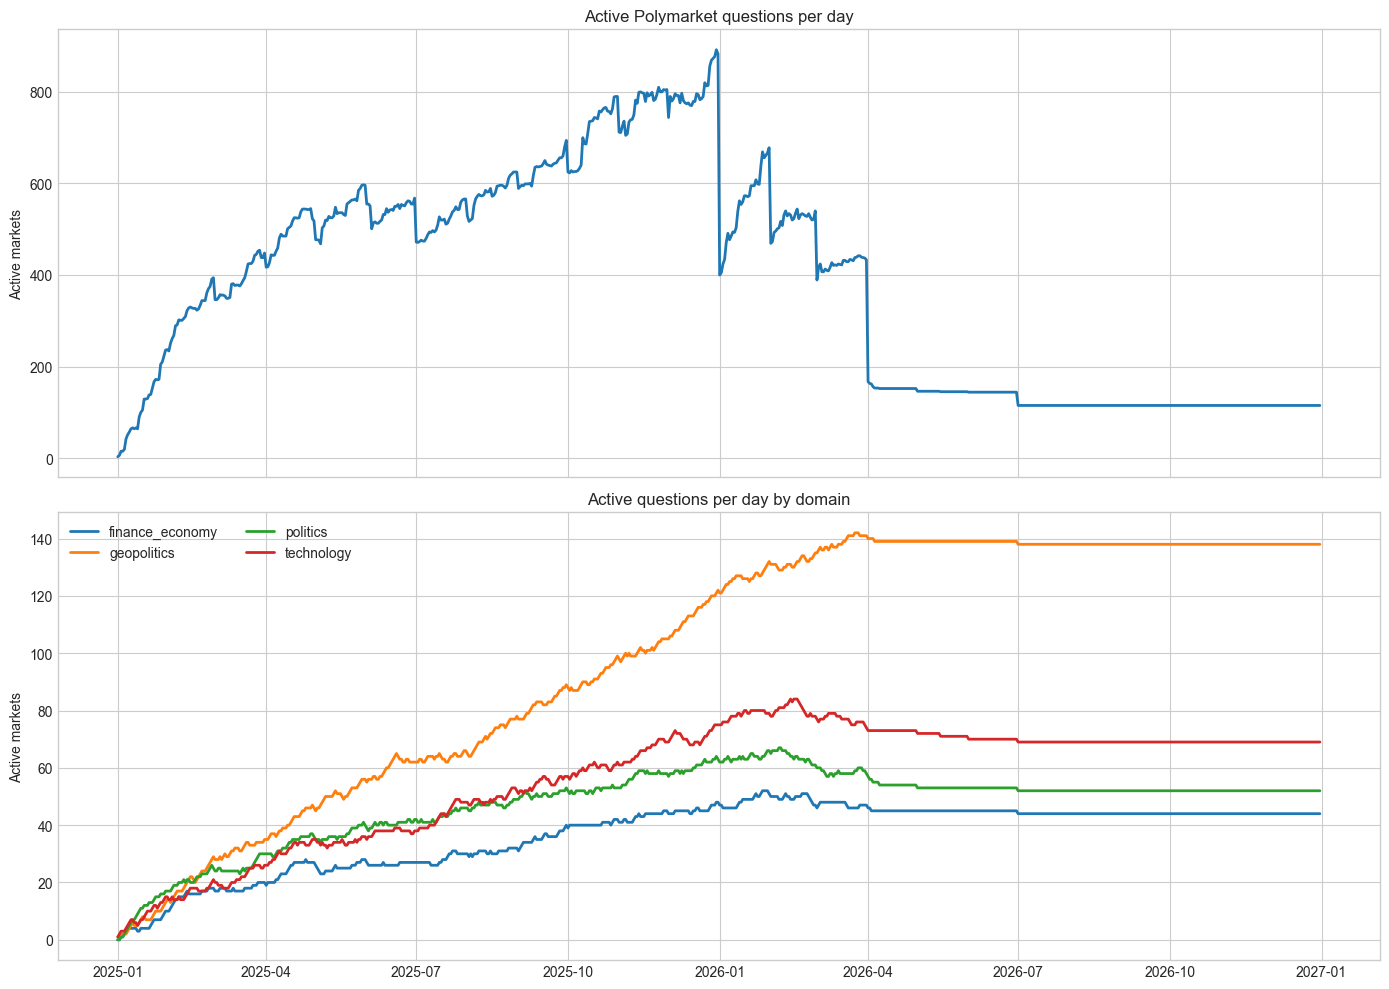

In [12]:
active_daily = build_active_markets_daily(markets)
active_daily_by_domain = build_active_markets_daily(markets, by_domain=True)

new_daily = (
    markets.assign(day=markets['created_at'].dt.floor('D'))
    .groupby('day', as_index=False)
    .size()
    .rename(columns={'size': 'new_markets'})
)
resolved_daily = (
    markets.assign(day=markets['end_date'].dt.floor('D'))
    .groupby('day', as_index=False)
    .size()
    .rename(columns={'size': 'resolved_markets'})
)

active_headline = active_daily.merge(new_daily, on='day', how='left').merge(resolved_daily, on='day', how='left').fillna(0)
display(active_headline.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(active_daily['day'], active_daily['active_markets'], linewidth=2, color='#1f77b4')
axes[0].set_title('Active Polymarket questions per day')
axes[0].set_ylabel('Active markets')

for domain, frame in active_daily_by_domain.groupby('primary_domain'):
    axes[1].plot(frame['day'], frame['active_markets'], linewidth=2, label=domain)
axes[1].set_title('Active questions per day by domain')
axes[1].set_ylabel('Active markets')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()


## Raw layer: daily market creation and resolution flow

Эта картинка дополняет предыдущую. Она отвечает на slightly different question:
- не сколько рынков активно одновременно,
- а насколько быстро вселенная рынков пополняется и закрывается.


,day,new_markets,resolved_markets,new_markets_30d,resolved_markets_30d
720,2026-12-22 00:00:00+00:00,0.0,0.0,0.0,0.000000
721,2026-12-23 00:00:00+00:00,0.0,0.0,0.0,0.000000
722,2026-12-24 00:00:00+00:00,0.0,0.0,0.0,0.000000
723,2026-12-25 00:00:00+00:00,0.0,0.0,0.0,0.000000
724,2026-12-26 00:00:00+00:00,0.0,0.0,0.0,0.000000
725,2026-12-27 00:00:00+00:00,0.0,0.0,0.0,0.000000
726,2026-12-28 00:00:00+00:00,0.0,0.0,0.0,0.000000
727,2026-12-29 00:00:00+00:00,0.0,0.0,0.0,0.000000
728,2026-12-30 00:00:00+00:00,0.0,0.0,0.0,0.000000
729,2026-12-31 00:00:00+00:00,0.0,29.0,0.0,0.966667


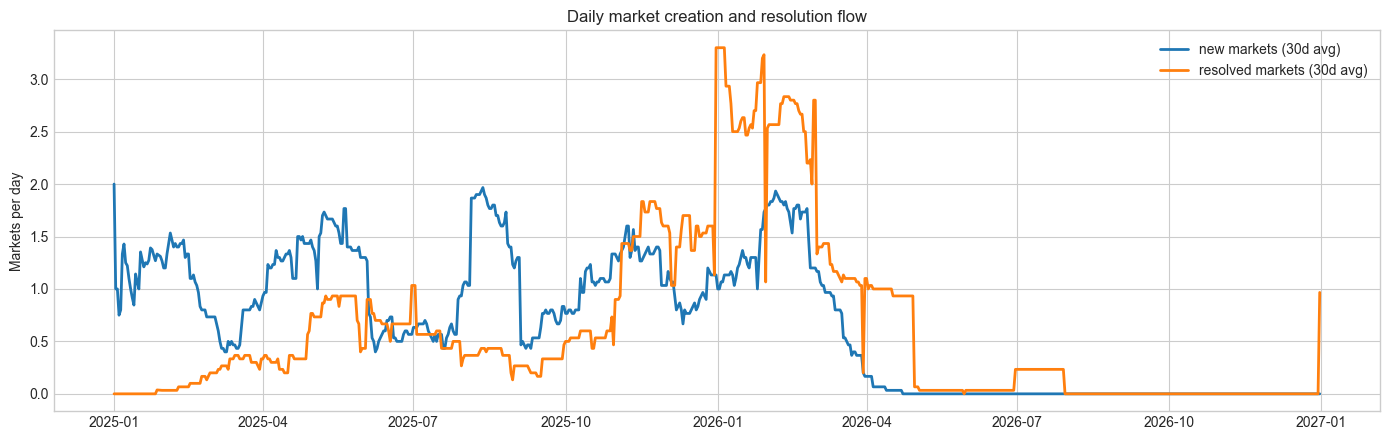

In [11]:
flow_daily = (
    active_daily[['day']]
    .merge(new_daily, on='day', how='left')
    .merge(resolved_daily, on='day', how='left')
    .fillna(0)
)

flow_daily['new_markets_30d'] = flow_daily['new_markets'].rolling(30, min_periods=1).mean()
flow_daily['resolved_markets_30d'] = flow_daily['resolved_markets'].rolling(30, min_periods=1).mean()

display(flow_daily.tail(10))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(flow_daily['day'], flow_daily['new_markets_30d'], label='new markets (30d avg)', linewidth=2)
ax.plot(flow_daily['day'], flow_daily['resolved_markets_30d'], label='resolved markets (30d avg)', linewidth=2)
ax.set_title('Daily market creation and resolution flow')
ax.set_ylabel('Markets per day')
ax.legend()
plt.tight_layout()
plt.show()


## Raw layer: probability activity over time

Теперь переходим к probability panel. Здесь мы смотрим на:
- сколько рынков реально наблюдается каждый день;
- сколько 5-minute rows приходит;
- сколько строк содержат observed trades;
- какой общий `total_size` проходит через наблюдаемую траекторию.

Это уже не metadata view, а activity view поверх траекторий вероятностей.


,day,active_markets_observed,probability_rows,observed_trade_rows,trade_count_sum,total_size_sum,observed_trade_share,total_size_sum_7d
447,2026-03-25 00:00:00+00:00,24,6912,4094,34377,1.636689e+07,0.592303,1.306039e+07
448,2026-03-26 00:00:00+00:00,24,6912,3923,36088,1.841217e+07,0.567564,1.351981e+07
449,2026-03-27 00:00:00+00:00,24,6912,4032,43163,1.305874e+07,0.583333,1.382444e+07
450,2026-03-28 00:00:00+00:00,24,6647,3751,28038,1.012505e+07,0.564315,1.402648e+07
451,2026-03-29 00:00:00+00:00,23,6624,3554,32624,1.439533e+07,0.536534,1.470329e+07
452,2026-03-30 00:00:00+00:00,23,6624,3253,46135,2.062255e+07,0.491093,1.497420e+07
453,2026-03-31 00:00:00+00:00,23,6084,2513,29557,1.935286e+07,0.413051,1.604766e+07
454,2026-04-01 00:00:00+00:00,17,1510,519,1294,1.767270e+06,0.343709,1.396200e+07
455,2026-04-02 00:00:00+00:00,1,288,89,225,3.516426e+05,0.309028,1.138192e+07
456,2026-04-03 00:00:00+00:00,1,124,15,36,1.021110e+04,0.120968,9.517844e+06


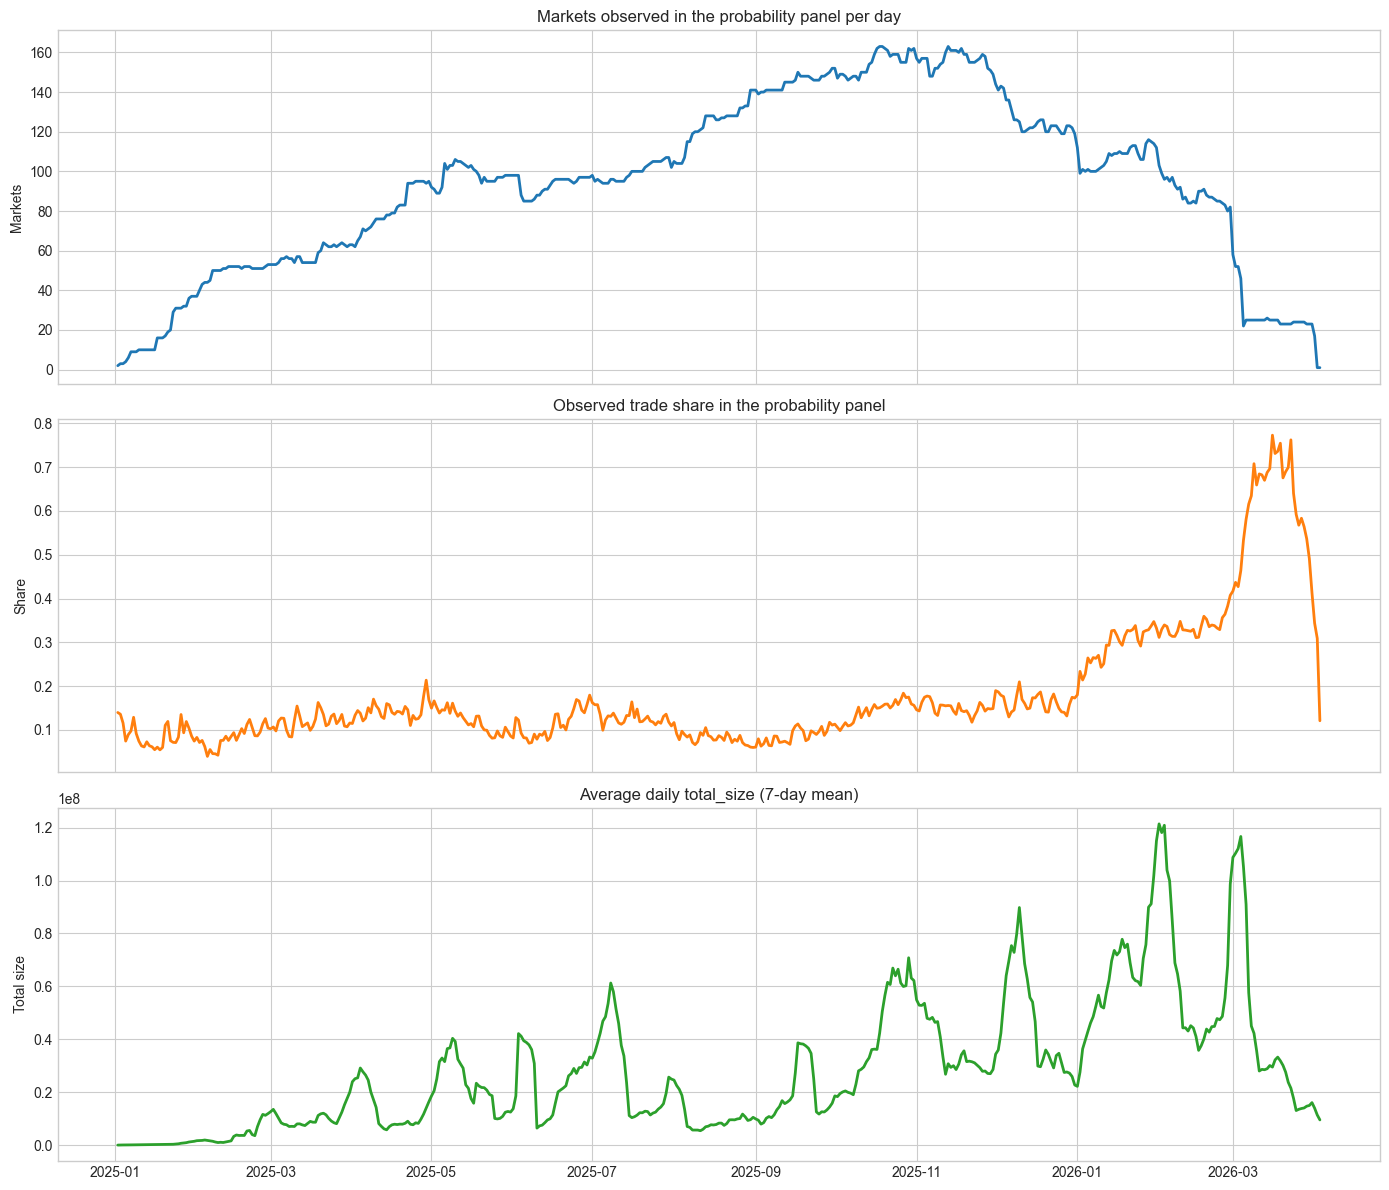

In [12]:
prob_with_domain = probabilities.merge(markets[['market_id', 'primary_domain']], on='market_id', how='left')
prob_with_domain['day'] = prob_with_domain['timestamp_utc'].dt.floor('D')

prob_daily = (
    prob_with_domain.groupby('day', as_index=False)
    .agg(
        active_markets_observed=('market_id', 'nunique'),
        probability_rows=('market_id', 'size'),
        observed_trade_rows=('observed_trade', 'sum'),
        trade_count_sum=('trade_count', 'sum'),
        total_size_sum=('total_size', 'sum'),
    )
    .sort_values('day', kind='stable')
)
prob_daily['observed_trade_share'] = prob_daily['observed_trade_rows'] / prob_daily['probability_rows'].replace(0, np.nan)
prob_daily['total_size_sum_7d'] = prob_daily['total_size_sum'].rolling(7, min_periods=1).mean()

prob_daily_by_domain = (
    prob_with_domain.groupby(['day', 'primary_domain'], as_index=False)
    .agg(
        active_markets_observed=('market_id', 'nunique'),
        observed_trade_rows=('observed_trade', 'sum'),
        total_size_sum=('total_size', 'sum'),
    )
    .sort_values(['day', 'primary_domain'], kind='stable')
)

display(prob_daily.tail(10))

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(prob_daily['day'], prob_daily['active_markets_observed'], linewidth=2)
axes[0].set_title('Markets observed in the probability panel per day')
axes[0].set_ylabel('Markets')

axes[1].plot(prob_daily['day'], prob_daily['observed_trade_share'], linewidth=2, color='#ff7f0e')
axes[1].set_title('Observed trade share in the probability panel')
axes[1].set_ylabel('Share')

axes[2].plot(prob_daily['day'], prob_daily['total_size_sum_7d'], linewidth=2, color='#2ca02c')
axes[2].set_title('Average daily total_size (7-day mean)')
axes[2].set_ylabel('Total size')
plt.tight_layout()
plt.show()


## Raw layer: probability activity by domain

Эта таблица показывает, как распределяется фактическая trajectory activity по доменам.

Самые важные колонки:
- `active_markets_observed`: сколько разных рынков реально активны в панели;
- `observed_trade_rows`: насколько часто мы видим trade-marked snapshots;
- `total_size_sum`: proxy на интенсивность наблюдаемого денежного потока.


,primary_domain,active_markets_observed,probability_rows,observed_trade_rows,trade_count_sum,total_size_sum,observed_trade_share
0,finance_economy,120,3172600,464580,3200966,3.899888e+09,0.146435
1,geopolitics,120,1835297,581019,5418566,3.540006e+09,0.316580
2,politics,120,3893192,405894,3216137,3.386646e+09,0.104257
3,technology,120,3409424,490169,3223619,2.092245e+09,0.143769


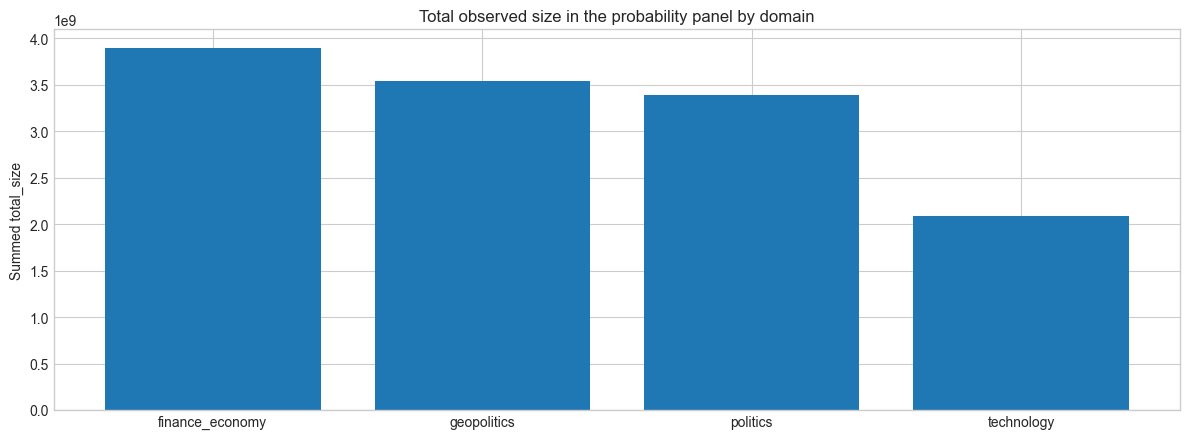

In [13]:
prob_domain_stats = (
    prob_with_domain.groupby('primary_domain', as_index=False)
    .agg(
        active_markets_observed=('market_id', 'nunique'),
        probability_rows=('market_id', 'size'),
        observed_trade_rows=('observed_trade', 'sum'),
        trade_count_sum=('trade_count', 'sum'),
        total_size_sum=('total_size', 'sum'),
    )
    .sort_values('total_size_sum', ascending=False, kind='stable')
)
prob_domain_stats['observed_trade_share'] = prob_domain_stats['observed_trade_rows'] / prob_domain_stats['probability_rows'].replace(0, np.nan)
display(prob_domain_stats)

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_frame = prob_domain_stats.sort_values('total_size_sum', ascending=False)
ax.bar(plot_frame['primary_domain'], plot_frame['total_size_sum'])
ax.set_title('Total observed size in the probability panel by domain')
ax.set_ylabel('Summed total_size')
plt.tight_layout()
plt.show()


## Raw external layer: available covariates

Сейчас внешний raw layer в проекте в основном представлен Binance crypto covariates и event-like external series.

Здесь важно проверить три вещи:
- какие `series_id` реально доступны;
- каков их coverage по времени;
- насколько плотны эти ряды.


In [14]:
external_summary_by_series = (
    external.groupby('series_id', as_index=False)
    .agg(
        rows=('timestamp_utc', 'size'),
        start=('timestamp_utc', 'min'),
        end=('timestamp_utc', 'max'),
        mean_value=('value', 'mean'),
        std_value=('value', 'std'),
    )
    .sort_values('rows', ascending=False, kind='stable')
)
display(external_summary_by_series)


,series_id,rows,start,end,mean_value,std_value
0,btc_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,96507.921255,15327.853669
1,eth_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,2931.216081,850.196262


## Raw external layer: normalized time series preview

Абсолютные масштабы у BTC и ETH разные, поэтому для сравнения удобнее нормировать ряды к `100` в первой точке.

Этот график нужен просто как sanity check: внешний cached layer действительно читается как плотный time series, а не как случайный набор строк.


,timestamp_utc,series_id,value,value_norm_100
0,2025-01-01 00:00:00+00:00,btc_usd,93661.20,100.000000
1,2025-01-01 00:05:00+00:00,btc_usd,93607.10,99.942239
2,2025-01-01 00:10:00+00:00,btc_usd,93656.18,99.994640
3,2025-01-01 00:15:00+00:00,btc_usd,93796.35,100.144297
4,2025-01-01 00:20:00+00:00,btc_usd,93740.00,100.084133


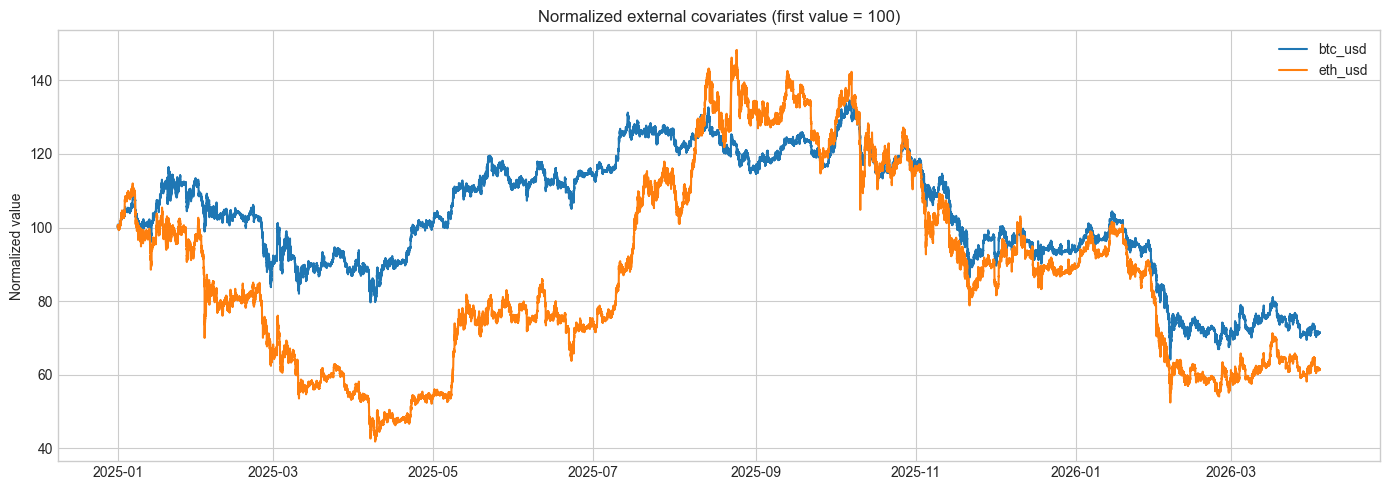

In [15]:
external_plot = external[['timestamp_utc', 'series_id', 'value']].dropna().copy()
external_plot = external_plot.sort_values(['series_id', 'timestamp_utc'], kind='stable')
external_plot['value_norm_100'] = external_plot.groupby('series_id')['value'].transform(lambda s: 100.0 * s / s.iloc[0] if len(s) else s)

display(external_plot.head())

fig, ax = plt.subplots(figsize=(14, 5))
for series_id, frame in external_plot.groupby('series_id'):
    ax.plot(frame['timestamp_utc'], frame['value_norm_100'], linewidth=1.5, label=series_id)
ax.set_title('Normalized external covariates (first value = 100)')
ax.set_ylabel('Normalized value')
ax.legend()
plt.tight_layout()
plt.show()


## Canonical layer: build and inspect

Теперь строим canonical layer.

Что он добавляет поверх raw tables:
- нормализованные типы и timestamp-поля;
- стабильное поле `domain`;
- weakly supervised `family_id`, которое потом удобно использовать для context aggregation.


In [16]:
canonical = CanonicalDatasetBuilder(raw_dataset=raw_dataset, raw_external=raw_external).build()

canonical_summary = pd.DataFrame([
    {'name': 'canonical_markets', 'rows': len(canonical.markets), 'cols': canonical.markets.shape[1]},
    {'name': 'canonical_probabilities', 'rows': len(canonical.probabilities), 'cols': canonical.probabilities.shape[1]},
    {'name': 'canonical_external_covariates', 'rows': 0 if canonical.external_covariates is None else len(canonical.external_covariates), 'cols': 0 if canonical.external_covariates is None else canonical.external_covariates.shape[1]},
])
display(canonical_summary)

added_market_columns = sorted(set(canonical.markets.columns) - set(markets.columns))
added_probability_columns = sorted(set(canonical.probabilities.columns) - set(probabilities.columns))
added_external_columns = sorted(set(canonical.external_covariates.columns) - set(external.columns)) if canonical.external_covariates is not None else []

display(pd.DataFrame({
    'layer': ['canonical markets', 'canonical probabilities', 'canonical external'],
    'new_columns': [', '.join(added_market_columns) or '(none)', ', '.join(added_probability_columns) or '(none)', ', '.join(added_external_columns) or '(none)']
}))


,name,rows,cols
0,canonical_markets,480,18
1,canonical_probabilities,12310513,7
2,canonical_external_covariates,263808,19


,layer,new_columns
0,canonical markets,"domain, family_id"
1,canonical probabilities,(none)
2,canonical external,(none)


## Canonical layer: family structure

`family_id` — это один из первых действительно полезных derived identifiers в текущей архитектуре.

Он не является ground truth family label, но нужен как weak structure для:
- sibling context,
- coherence proxies,
- retrieval-style baselines.

Здесь мы смотрим, насколько крупными получаются такие weak families.


,primary_domain,families,mean_family_size,median_family_size,max_family_size,singleton_share
2,politics,119,1.008403,1.0,2,0.991597
1,geopolitics,118,1.016949,1.0,2,0.983051
3,technology,111,1.081081,1.0,3,0.936937
0,finance_economy,108,1.111111,1.0,2,0.888889


,primary_domain,family_id,family_size
390,technology,technology::big tech|business|economy::nvidia largest company world market cap,3
450,technology,technology::games|soccer|sports::paris saint germain fc win on,3
4,finance_economy,finance_economy::all|economy|fed::fed decreases interest rates 25 bps,2
5,finance_economy,finance_economy::all|economy|fed::fed decreases interest rates 50 bps,2
6,finance_economy,finance_economy::all|economy|fed::fed increases interest rates 25 bps,2
7,finance_economy,finance_economy::all|economy|fed::no change fed interest rates after,2
44,finance_economy,finance_economy::comex silver futures|commodities|finance::silver si hit high 120 end,2
63,finance_economy,finance_economy::economic policy|economy|fed::fed decreases interest rates 25 bps,2
64,finance_economy,finance_economy::economic policy|economy|fed::fed decreases interest rates 50 bps,2
66,finance_economy,finance_economy::economic policy|economy|fed::fed increases interest rates 25 bps,2


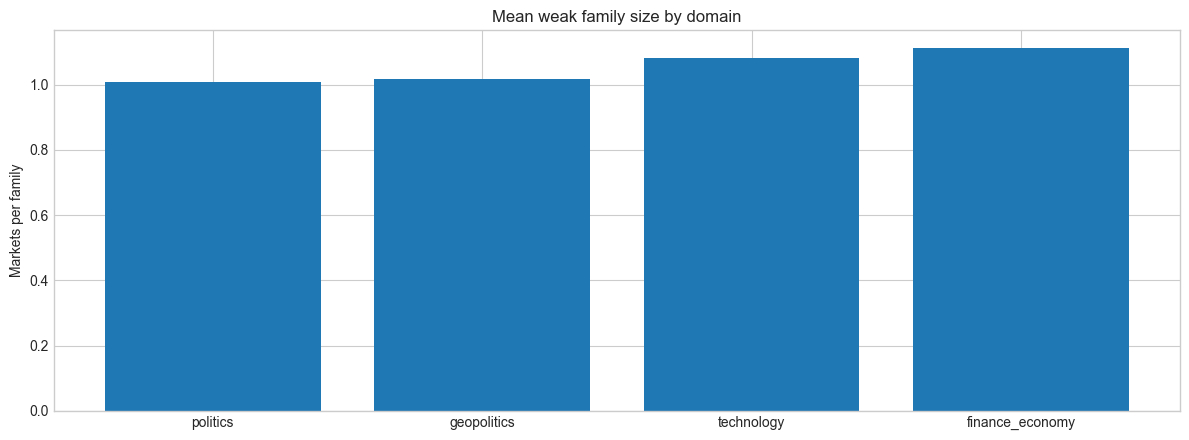

In [17]:
family_sizes = (
    canonical.markets.groupby(['primary_domain', 'family_id'], as_index=False)
    .agg(family_size=('market_id', 'nunique'))
)

family_stats = (
    family_sizes.groupby('primary_domain', as_index=False)
    .agg(
        families=('family_id', 'nunique'),
        mean_family_size=('family_size', 'mean'),
        median_family_size=('family_size', 'median'),
        max_family_size=('family_size', 'max'),
        singleton_share=('family_size', lambda s: float((s == 1).mean())),
    )
    .sort_values('families', ascending=False, kind='stable')
)

display(family_stats)
display(family_sizes.sort_values('family_size', ascending=False, kind='stable').head(12))

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_frame = family_stats.sort_values('families', ascending=False)
ax.bar(plot_frame['primary_domain'], plot_frame['mean_family_size'])
ax.set_title('Mean weak family size by domain')
ax.set_ylabel('Markets per family')
plt.tight_layout()
plt.show()


## Filesystem workflow for raw and canonical layers

Теперь у текущих слоёв есть нормальный lifecycle не только в памяти, но и на файловой системе.

Это важно по двум причинам:
- можно сохранять промежуточные representations как стабильные артефакты;
- можно потом поднимать их обратно без повторной загрузки из SQLite и без повторной canonicalization.

Ниже мы делаем маленький temporary round-trip для трёх объектов:
- raw external covariates;
- canonical dataset;
- derived `DataBundle`.


In [18]:
filesystem_manifest = None

with tempfile.TemporaryDirectory() as tmp_dir:
    tmp_dir = Path(tmp_dir)

    external_path = raw_external.save(tmp_dir / 'raw_external_covariates.parquet')
    external_reloaded = RawExternalCovariates.from_parquet(external_path)

    canonical_dir = tmp_dir / 'canonical_dataset'
    canonical_manifest = canonical.save(canonical_dir)
    canonical_reloaded = canonical.from_parquet(canonical_dir)

    bundle_for_fs = PolymarketDatasetBuilder().build()
    bundle_dir = tmp_dir / 'derived_bundle'
    bundle_manifest = bundle_for_fs.save(bundle_dir)
    bundle_reloaded = bundle_for_fs.from_parquet(bundle_dir)

    filesystem_manifest = pd.concat(
        [
            pd.DataFrame([
                {
                    'layer': 'raw_external',
                    'path': str(external_path),
                    'rows': len(external_reloaded.covariates),
                    'cols': external_reloaded.covariates.shape[1],
                }
            ]),
            canonical_manifest.assign(layer='canonical'),
            bundle_manifest.assign(layer='bundle'),
        ],
        ignore_index=True,
    )

    filesystem_summary = pd.DataFrame([
        {
            'object': 'raw_external_reloaded',
            'rows': len(external_reloaded.covariates),
            'cols': external_reloaded.covariates.shape[1],
        },
        {
            'object': 'canonical_reloaded_markets',
            'rows': len(canonical_reloaded.markets),
            'cols': canonical_reloaded.markets.shape[1],
        },
        {
            'object': 'bundle_reloaded_terminal',
            'rows': len(bundle_reloaded.terminal),
            'cols': bundle_reloaded.terminal.shape[1],
        },
    ])


display(filesystem_manifest)
display(filesystem_summary)


,layer,path,rows,cols,file
0,raw_external,/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/tmpgk5tzl_a/raw_external_covariates.parquet,263808,19,NaN
1,canonical,NaN,480,18,markets.parquet
2,canonical,NaN,12310513,7,probabilities.parquet
3,canonical,NaN,263808,19,external_covariates.parquet
4,bundle,NaN,480,17,markets.parquet
5,bundle,NaN,12310513,7,probabilities.parquet
6,bundle,NaN,966,51,terminal.parquet
7,bundle,NaN,80755,36,repricing.parquet
8,bundle,NaN,131904,8,shock_table.parquet


,object,rows,cols
0,raw_external_reloaded,263808,19
1,canonical_reloaded_markets,480,18
2,bundle_reloaded_terminal,966,51


Здесь важны две вещи:
- `path` / `file` показывает, как именно слой раскладывается на диске;
- `rows` и `cols` после round-trip нужны как sanity check, что save/load не ломает representation.

После этой точки data layers уже можно использовать не только как runtime objects, но и как явные reproducible artefacts.


## Derived representation layer: reusable research bundle

Этот слой уже выходит за рамки просто хранения таблиц. Здесь мы строим reusable panels:
- `terminal`;
- `repricing`;
- `shock_table`.

Это важный слой, потому что именно он соединяет data architecture с benchmark/evaluation layer.


In [19]:
bundle = PolymarketDatasetBuilder().build()
bundle_summary = bundle.summary().copy()
bundle_summary['rows_human'] = bundle_summary['rows'].map(format_large_number)
display(bundle_summary)


,name,rows,cols,rows_human
0,markets,480,17,480.00
1,probabilities,12310513,7,12.31M
2,terminal,966,51,966.00
3,repricing,80755,36,80.8K
4,shock_table,131904,8,131.9K


## Derived layer: terminal panel

У `terminal` panel главные поля такие:
- `horizon_hours`: на каком горизонте взят snapshot;
- `target`: финальный binary outcome;
- `market_price_baseline`: базовая рыночная вероятность на cutoff;
- `family_*`: первые context-агрегаты поверх weak structure.

Сначала смотрим таблицу покрытия по горизонтам и доменам.


,horizon_name,primary_domain,rows,markets,target_rate,baseline_log_loss,mean_confidence_margin,mean_family_gap
0,1d,finance_economy,97,97,0.237113,0.221751,0.443226,0.000000
2,1d,politics,83,83,0.240964,0.259236,0.415084,0.000000
1,1d,geopolitics,76,76,0.236842,0.381366,0.412921,0.000000
3,1d,technology,61,61,0.278689,0.220753,0.397951,0.068308
4,3d,finance_economy,99,99,0.242424,0.257660,0.449537,0.000000
6,3d,politics,84,84,0.238095,0.243827,0.409529,0.000000
5,3d,geopolitics,75,75,0.266667,0.474436,0.414435,0.000000
7,3d,technology,64,64,0.281250,0.203146,0.396734,0.013000
8,7d,finance_economy,101,101,0.267327,0.247515,0.437567,0.000000
10,7d,politics,87,87,0.218391,0.271727,0.401573,NaN


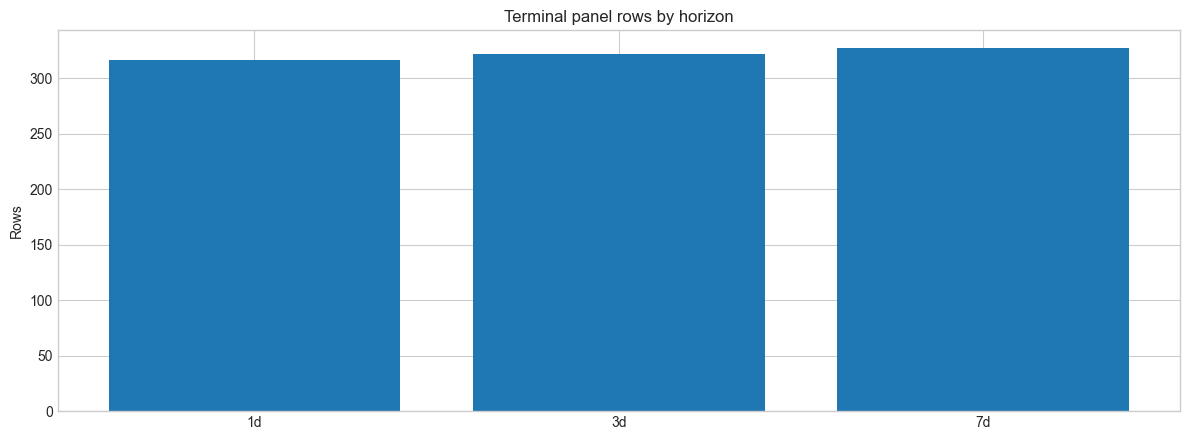

In [20]:
terminal = bundle.terminal.copy()
terminal_stats = (
    terminal.groupby(['horizon_name', 'primary_domain'], as_index=False)
    .agg(
        rows=('market_id', 'size'),
        markets=('market_id', 'nunique'),
        target_rate=('target', 'mean'),
        baseline_log_loss=('market_log_loss', 'mean'),
        mean_confidence_margin=('confidence_margin', 'mean'),
        mean_family_gap=('family_prob_gap', 'mean'),
    )
    .sort_values(['horizon_name', 'rows'], ascending=[True, False], kind='stable')
)
display(terminal_stats)

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_frame = terminal.groupby('horizon_name', as_index=False).size().rename(columns={'size': 'rows'})
ax.bar(plot_frame['horizon_name'], plot_frame['rows'])
ax.set_title('Terminal panel rows by horizon')
ax.set_ylabel('Rows')
plt.tight_layout()
plt.show()


## Derived layer: repricing panel

`repricing` panel — это уже динамическое representation, где target зависит от будущего движения вероятности.

Самые важные колонки:
- `target`: случился ли large repricing;
- `recent_volatility`, `recent_abs_move_*`: локальная рыночная динамика;
- `btc_usd_*`, `eth_usd_*`: внешние shock-признаки после as-of join.


,primary_domain,rows,markets,target_rate,mean_recent_volatility,mean_trade_count_sum,btc_or_eth_shock_rate
2,politics,25228,116,0.005232,0.001310,176.389012,0.083162
3,technology,22979,116,0.009356,0.001497,246.057835,0.076592
0,finance_economy,20993,118,0.016767,0.002514,267.833564,0.075073
1,geopolitics,11555,103,0.026482,0.003980,679.939334,0.070359


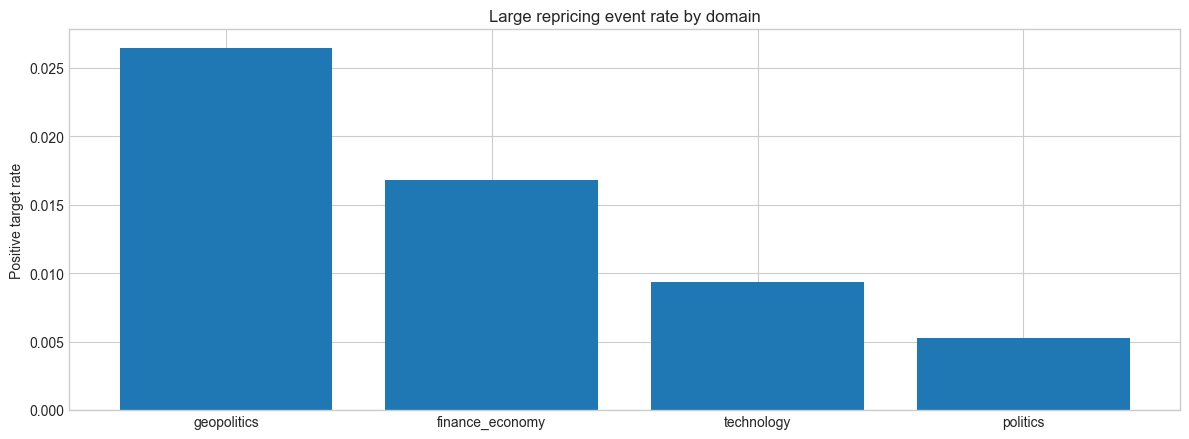

In [21]:
repricing = bundle.repricing.copy()
repricing_stats = (
    repricing.groupby('primary_domain', as_index=False)
    .agg(
        rows=('market_id', 'size'),
        markets=('market_id', 'nunique'),
        target_rate=('target', 'mean'),
        mean_recent_volatility=('recent_volatility', 'mean'),
        mean_trade_count_sum=('trade_count_sum', 'mean'),
        btc_or_eth_shock_rate=('btc_or_eth_shock', 'mean'),
    )
    .sort_values('rows', ascending=False, kind='stable')
)
display(repricing_stats)

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_frame = repricing_stats.sort_values('target_rate', ascending=False)
ax.bar(plot_frame['primary_domain'], plot_frame['target_rate'])
ax.set_title('Large repricing event rate by domain')
ax.set_ylabel('Positive target rate')
plt.tight_layout()
plt.show()


## Derived layer: shock table

`shock_table` — это отдельное representation внешнего мира, полученное из external covariates.

Главный смысл этого слоя:
- из простого time series сделать reusable event-like features;
- потом приклеивать их к event panels через time-safe as-of joins.


,metric,value
0,rows,131904.000000
1,btc_shock_rate,0.055343
2,eth_shock_rate,0.051947
3,any_external_shock_rate,0.077784


,timestamp_utc,btc_usd_ret,btc_usd_z,btc_usd_shock,eth_usd_ret,eth_usd_z,eth_usd_shock,any_external_shock
0,2025-01-01 00:00:00+00:00,NaN,NaN,0.0,NaN,NaN,0.0,0.0
1,2025-01-01 00:05:00+00:00,-0.000578,NaN,0.0,0.000817,NaN,0.0,0.0
2,2025-01-01 00:10:00+00:00,0.000524,NaN,0.0,0.001648,NaN,0.0,0.0
3,2025-01-01 00:15:00+00:00,0.001497,NaN,0.0,0.000762,NaN,0.0,0.0
4,2025-01-01 00:20:00+00:00,-0.000601,NaN,0.0,-0.000513,NaN,0.0,0.0


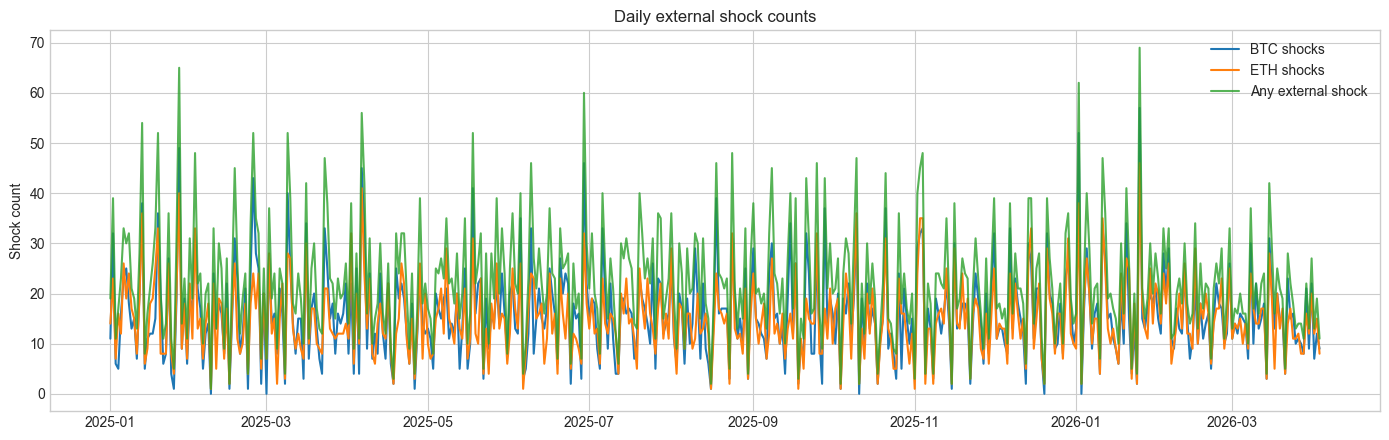

In [22]:
shock_table = bundle.shock_table.copy()
shock_summary = pd.DataFrame([
    {
        'metric': 'rows',
        'value': len(shock_table),
    },
    {
        'metric': 'btc_shock_rate',
        'value': float(shock_table['btc_usd_shock'].mean()),
    },
    {
        'metric': 'eth_shock_rate',
        'value': float(shock_table['eth_usd_shock'].mean()),
    },
    {
        'metric': 'any_external_shock_rate',
        'value': float(shock_table['any_external_shock'].mean()),
    },
])
display(shock_summary)
display(shock_table.head())

shock_daily = (
    shock_table.assign(day=shock_table['timestamp_utc'].dt.floor('D'))
    .groupby('day', as_index=False)
    .agg(
        btc_shocks=('btc_usd_shock', 'sum'),
        eth_shocks=('eth_usd_shock', 'sum'),
        any_shocks=('any_external_shock', 'sum'),
    )
)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(shock_daily['day'], shock_daily['btc_shocks'], label='BTC shocks', linewidth=1.5)
ax.plot(shock_daily['day'], shock_daily['eth_shocks'], label='ETH shocks', linewidth=1.5)
ax.plot(shock_daily['day'], shock_daily['any_shocks'], label='Any external shock', linewidth=1.5, alpha=0.8)
ax.set_title('Daily external shock counts')
ax.set_ylabel('Shock count')
ax.legend()
plt.tight_layout()
plt.show()


## Что уже можно считать реализованными data layers

По итогам notebook текущая архитектура уже даёт нам такие рабочие уровни:

1. **Raw Polymarket layer**
   - `markets`
   - `probabilities`
   - raw external covariates

2. **Canonical layer**
   - typed timestamps
   - stable `domain`
   - weak `family_id`

3. **Derived research panels**
   - `terminal`
   - `repricing`
   - `shock_table`

Это уже достаточно, чтобы поверх data architecture строить:
- benchmark tasks;
- retrieval/context baselines;
- будущие latent-state / encoder ideas.
